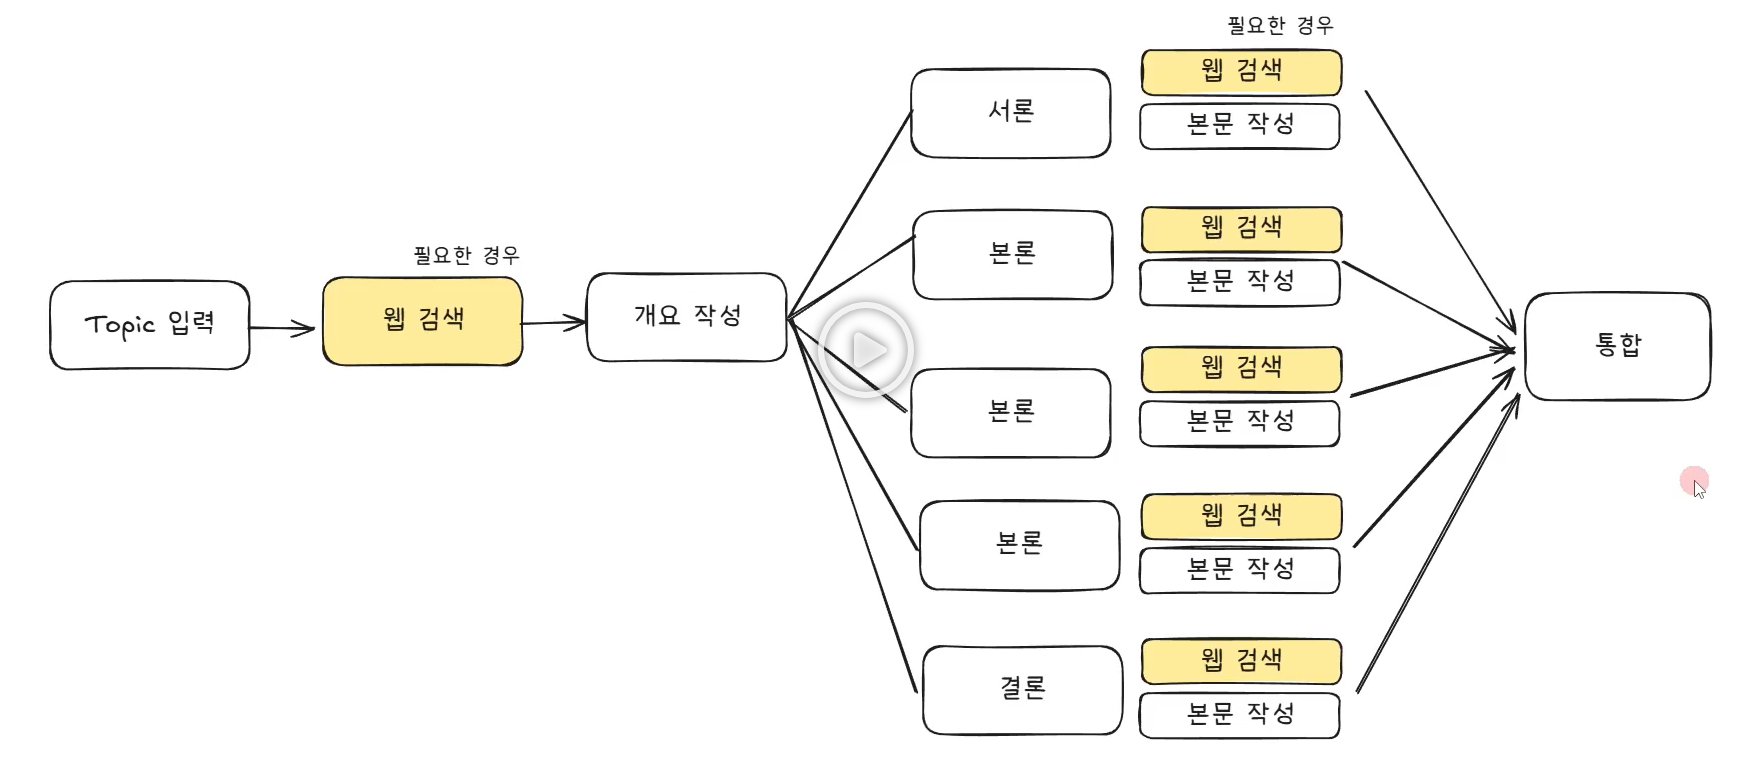

In [11]:
# 필요한 라이브러리 설치 및 임포트
import os
import operator
from typing import TypedDict, Annotated, List
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
# from langgraph.types import Send 
from exa_py import Exa

load_dotenv()

# LLM 및 Exa 초기화
outline_llm = ChatOpenAI(model="gpt-5-mini", temperature=1) # 개요
writer_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.5) # 본문 
exa = Exa(api_key=os.environ.get("EXA_API_KEY"))

- ReportState: 전반적인 데이터 구조 정의 TypeDict 클래스

In [7]:
# State 정의
class ReportState(TypedDict):
    topic: str # 보고서 주제
    outline: str # 개요

    # 각 섹션별 내용
    intro_content: str
    body1_content: str
    body2_content: str
    body3_content: str
    conclusion_content: str

    final_report: str # 최종 보고서

- web search 함수 정의

In [10]:
from langchain_core.tools import tool

@tool
def web_search(
    query: str, 
    num_results: int = 3, # 최대 100개까지 지정 가능
    search_type: str = "neural", # neural(시맨틱), keyword, auto
    max_characters: int = 3000, # 텍스트 최대 길이
) -> str:
    """
    Exa를 사용한 웹 검색
    
    Args:
        query: 검색 쿼리
        num_results: 반환할 결과 수
        search_type: 검색 유형 (neural=시맨틱/keyword=키워드/auto=자동선택)
        max_characters: 텍스트 최대 문자 수
    """
    try:
        # 검색 파라미터 구성 (단순화)
        search_params = {
            "query": query,
            "type": search_type,
            "num_results": num_results,
            "text": {"max_characters": max_characters},
            "highlights": True # 하이라이트 기본 활성화
        }
        
        results = exa.search_and_contents(**search_params)
        
        search_results = []
        for result in results.results:
            # 기본 정보 구성
            result_text = f"📌 제목: {result.title}\n"
            result_text += f"🔗 URL: {result.url}\n"
            
            # 발행일 정보 (있는 경우)
            if hasattr(result, 'published_date') and result.published_date:
                result_text += f"📅 발행일: {result.published_date}\n"
            
            # 하이라이트 (핵심 문장들)
            if hasattr(result, 'highlights') and result.highlights:
                result_text += "\n💡 핵심 내용:\n"
                for i, highlight in enumerate(result.highlights, 1):
                    result_text += f"  {i}. {highlight.strip()}\n"
            
            # 본문 텍스트
            if hasattr(result, 'text') and result.text:
                text_preview = result.text[:max_characters]
                if len(result.text) > max_characters:
                    text_preview += "..."
                result_text += f"\n📄 본문:\n{text_preview}"
            
            search_results.append(result_text)
        
        # 검색 메타 정보 추가
        header = f"🔍 검색어: \"{query}\" | 결과: {len(results.results)}건\n"
        header += "=" * 60 + "\n\n"
        
        return header + "\n\n---\n\n".join(search_results)
            
    except Exception as e:
        return f"검색 실패: {str(e)}"

- 노드 함수 정의
    - ReACT 방식
    - ToolCallLimitMiddleware
        - 미들웨어: 내가 원하는 방향대로
        - 도구 호출 제한 미들웨어

In [13]:
# 노드 함수들
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from langchain.agents.middleware import ToolCallLimitMiddleware


class OutlineStructure(BaseModel):
    """보고서 개요 구조"""
    서론: str = Field(description="서론에서 다룰 내용")
    본론1: str = Field(description="본론1에서 다룰 내용")
    본론2: str = Field(description="본론2에서 다룰 내용")
    본론3: str = Field(description="본론3에서 다룰 내용")
    결론: str = Field(description="결론에서 다룰 내용")

def create_outline(state: ReportState) -> ReportState:
    """주제에 대해 웹 검색 후 개요 작성"""
    topic = state["topic"]
    
    # 에이전트 생성 (웹 검색 도구 포함, structured output 강제)
    tools = [web_search]
    outline_agent = create_agent(
        outline_llm, 
        tools,
        response_format=OutlineStructure
    )
    
    # 개요 생성 요청
    prompt = f"""
주제: {topic}

위 주제에 대해 보고서 개요를 작성해주세요.

**중요: 최신 정보와 트렌드를 파악하기 위해 반드시 웹 검색을 먼저 수행하세요.**

검색 결과를 바탕으로 다음 구조로 개요를 작성해주세요:
1. 서론
2. 본론1
3. 본론2
4. 본론3
5. 결론

각 섹션에서 다룰 내용을 간략히 설명해주세요.
"""
    
    result = outline_agent.invoke({"messages": [{"role": "user", "content": prompt}]})
    
    return {
        "outline": result["messages"][-1].content
    }
def _write_section_common(state: ReportState, section_name: str) -> str:
    """공통 섹션 작성 로직"""
    topic = state["topic"]
    outline = state["outline"]
    
    # 에이전트 생성 (웹 검색 도구 포함 및 검색 횟수 제한 미들웨어 추가)
    tools = [web_search]
    section_agent = create_agent(
        writer_llm, 
        tools,
        middleware=[
            ToolCallLimitMiddleware( # 미들 웨어
                tool_name="web_search",
                run_limit=3
            )
        ]
    )
    
    prompt = f"""
보고서 주제: {topic}

전체 개요:
{outline}

현재 작성할 섹션: {section_name}

**중요: 해당 섹션에 대한 상세 정보를 얻기 위해 필요한 만큼 웹 검색을 수행하세요.**

검색 옵션 (우선 사용):
- query: "{topic} {section_name} 상세 내용"
- num_results: 3
- use_highlights: True
- max_characters: 3000
- livecrawl: "fallback"

필요하다면 여러 번 검색하여 충분한 정보를 수집한 후, 검색 결과를 바탕으로 위 섹션의 내용을 상세하게 작성해주세요. 
- 명확하고 논리적인 문장으로 작성
- 적절한 소제목 사용 가능
- 3000자 분량
"""
    result = section_agent.invoke({"messages": [{"role": "user", "content": prompt}]})
    return result["messages"][-1].content

- 개요: create_outline
- 본문: _write_section_common

    - 서론
    - 본론1
    - 본론2
    - 본론3
    - 결론

In [14]:
def write_intro(state: ReportState) -> dict:
    content = _write_section_common(state, "서론")
    return {"intro_content": content}

def write_body1(state: ReportState) -> dict:
    content = _write_section_common(state, "본론1")
    return {"body1_content": content}

def write_body2(state: ReportState) -> dict:
    content = _write_section_common(state, "본론2")
    return {"body2_content": content}

def write_body3(state: ReportState) -> dict:
    content = _write_section_common(state, "본론3")
    return {"body3_content": content}

def write_conclusion(state: ReportState) -> dict:
    content = _write_section_common(state, "결론")
    return {"conclusion_content": content}

In [ ]:
def compile_report(state: ReportState) -> ReportState:
    """모든 섹션을 통합하여 최종 보고서 생성"""
    topic = state["topic"]
    
    report_parts = [f"# {topic}\n"]
    
    sections = [
        ("서론", state.get("intro_content", "")),
        ("본론1", state.get("body1_content", "")),
        ("본론2", state.get("body2_content", "")),
        ("본론3", state.get("body3_content", "")),
        ("결론", state.get("conclusion_content", ""))
    ]
    
    for title, content in sections:
        report_parts.append(f"\n## {title}\n{content}\n")
    
    final_report = "\n".join(report_parts)
    
    return {"final_report": final_report}

In [16]:
# 그래프 빌드
workflow = StateGraph(ReportState)

# 노드 추가
workflow.add_node("create_outline", create_outline)
workflow.add_node("write_intro", write_intro)
workflow.add_node("write_body1", write_body1)
workflow.add_node("write_body2", write_body2)
workflow.add_node("write_body3", write_body3)
workflow.add_node("write_conclusion", write_conclusion)
workflow.add_node("compile_report", compile_report)

# 엣지 연결
workflow.add_edge(START, "create_outline")

# 정적 병렬 연결 (Fan-out)
workflow.add_edge("create_outline", "write_intro")
workflow.add_edge("create_outline", "write_body1")
workflow.add_edge("create_outline", "write_body2")
workflow.add_edge("create_outline", "write_body3")
workflow.add_edge("create_outline", "write_conclusion")

# 통합 노드로 연결 (Fan-in)
workflow.add_edge("write_intro", "compile_report")
workflow.add_edge("write_body1", "compile_report")
workflow.add_edge("write_body2", "compile_report")
workflow.add_edge("write_body3", "compile_report")
workflow.add_edge("write_conclusion", "compile_report")

workflow.add_edge("compile_report", END)

# 컴파일
graph = workflow.compile()


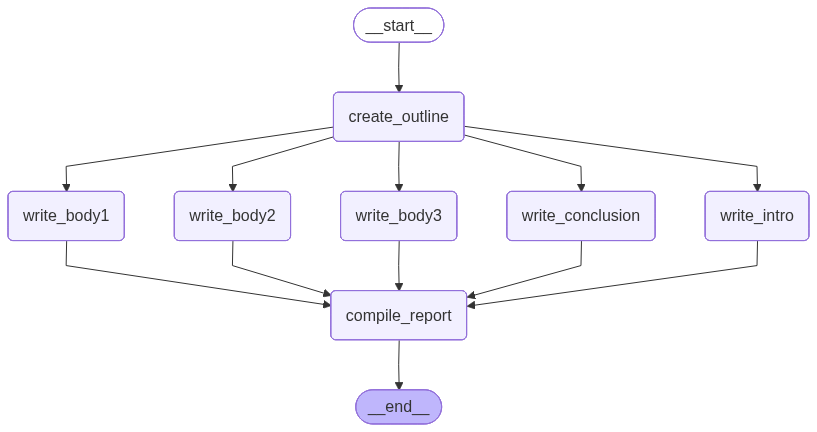

In [17]:
# 그래프 시각화
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [18]:
inputs = {"topic": "닥스훈트"}

for chunk in graph.stream(
    inputs,
    # Set subgraphs=True to stream outputs from subgraphs
    subgraphs=True, # 서브에 서브를 넣어주고 있기 때문 
    stream_mode="updates",
):
    print(chunk)

((), {'create_outline': {'outline': '{"서론":"닥스훈트의 정의와 기원(독일의 오소리 사냥개), 오늘날 반려견으로서의 인기와 최근 동향 요약 — 국내외에서의 인기 확산, 정보·상품(맞춤 사료·리하빌리테이션 등) 증가, 평균 수명(약 12~16년) 언급.","본론1":"품종적 특징 — 외형(짧은 다리·긴 몸), 크기 구분(스탠더드·미니어처·카니헨), 모질 유형(단모·장모·와이어)과 색상/무늬(레드, 블랙앤탄, 더플 등). 이 체형이 주는 장단점(매력·특이성 vs. 척추·관절 취약성)을 간략히 설명.","본론2":"성격·행동·훈련 — 용감하고 호기심 많은 반면 고집이 셀 수 있음, 가족에 대한 애착과 경계심(짖음) 특성. 사회화의 중요성, 긍정적 강화 기반의 일관된 훈련법, 분리불안·과잉 짖음 예방 팁과 실내 활동(정기적 산책·놀이) 권장.","본론3":"건강·관리 및 최신 트렌드 — 척추질환(IVDD) 취약성(관련 통계와 예방의 중요성), 체중 관리의 결정적 역할(체중 변화가 허리 부담에 미치는 영향), 연령별 영양·운동 권장, 모질별 그루밍과 귀·치아 관리. 최신 트렌드: 맞춤 영양(브랜드별 품종별 사료), 예방 중심의 물리치료·재활 서비스 증가, 펫보험·유전검사·윤리적 분양·구조 입양에 대한 관심 상승.","결론":"핵심 요약 — 닥스훈트는 매력적이지만 체형 특유의 건강 리스크(특히 척추) 관리가 최우선. 실천 권장사항: 정기 수의사 검진, 체중·운동·영양 관리, 조기 사회화·일관된 훈련, 신뢰할 수 있는 분양(또는 입양)처 선택. 최신 정보는 수의사 및 공신력 있는 자료로 주기적 확인 권장."}'}})
((), {'write_conclusion': {'conclusion_content': '닥스훈트 결론 상세 내용 정리\n\n1. 닥스훈트의 매력과 건강 리스크 관리의 중요성\n닥스훈트는 독일에서 오소리 사냥개로 개량된 독특한 체형(긴 몸통과 짧은 다리)과 귀여운 외모로 전 세계적으로 인기 있는 반려견입니다. 그러나 이 체형 특

In [19]:
inputs = {"topic": "닥스훈트"}
print(f"🚀 보고서 작성을 시작합니다: '{inputs['topic']}'\n")

last_node = None
final_report = "" 

for chunk in graph.stream(inputs, subgraphs=True, stream_mode="updates"):
    namespace, update = chunk
    
    if not namespace:
        # 구조 1: update['final_report'] 직접 존재
        if 'final_report' in update:
            final_report = update['final_report']
        # 구조 2: update['compile_report']['final_report'] 형태로 존재 (노드 이름으로 감싸진 경우)
        else:
            for node_data in update.values():
                if isinstance(node_data, dict) and 'final_report' in node_data:
                    final_report = node_data['final_report']
        continue
        
    node_name = namespace[-1]
    clean_name = node_name.split(':')[0] if ':' in node_name else node_name

    if clean_name != last_node:
        print(f"\n{'='*40}")
        print(f"🔄 단계: {clean_name}")
        print(f"{'='*40}")
        last_node = clean_name

    # 도구 및 모델 진행 상황 출력
    if 'tools' in update:
        msgs = update['tools'].get('messages', [])
        if msgs:
            content = getattr(msgs[0], 'content', "")
            header = content.split('\n')[0] if content else "검색 완료"
            print(f"  🔍 {header}")
            
    elif 'model' in update:
        msgs = update['model'].get('messages', [])
        if msgs:
            msg_content = getattr(msgs[0], 'content', "")
            if msg_content:
                print(f"  📝 생성 중: {msg_content[:100]}...")

    # 섹션 완료 상태 출력
    if isinstance(update, dict):
        for key in update:
            if key.endswith('_content'):
                print(f"  ✅ {key.replace('_content','')} 작성 완료")

# --- 최종 결과 출력 및 저장 ---
print("\n" + "="*50)
if final_report:
    print("✨ 보고서 작성이 최종 완료되었습니다!")
    
    file_name = f"report_{inputs['topic'].replace(' ', '_')}.md"
    with open(file_name, "w", encoding="utf-8") as f:
        f.write(final_report)
    
    print(f"💾 파일 저장 완료: {file_name}")
    print(f"\n[보고서 미리보기]\n{'-'*20}\n{final_report[:500]}...")
else:
    print("❌ 스트리밍이 끝났으나 'final_report'를 수집하지 못했습니다.")
    print("그래프의 마지막 노드에서 'final_report' 키를 반환하는지 확인해 주세요.")

🚀 보고서 작성을 시작합니다: '닥스훈트'


✨ 보고서 작성이 최종 완료되었습니다!
💾 파일 저장 완료: report_닥스훈트.md

[보고서 미리보기]
--------------------
# 닥스훈트


## 서론
서론: 닥스훈트의 개요와 주제 소개

1. 닥스훈트의 유래와 역사
닥스훈트(Dachshund)는 독일에서 기원한 사냥개 품종으로, 이름은 독일어로 ‘오소리 개’를 뜻한다. 본래 오소리나 두더지 같은 굴 속에 숨어 사는 작은 동물을 사냥하기 위해 개발되었다. 닥스훈트의 조상견은 스위스 산악 지방의 쥬라 하운드와 독일 및 오스트리아 산악지대의 핀셔, 테리어 등이 교배되어 탄생했다. 15세기부터 품종 개량이 시작되었으며, 19세기에는 독일 왕실과 유럽 귀족들 사이에서 큰 인기를 누렸다. 이후 19세기 중반 미국에 소개되어 1885년 미국 개 종합협회에 공식 등록되면서 세계적으로 알려지게 되었다. 1차, 2차 세계대전 중에는 독일의 상징으로 여겨져 미국 등지에서 인기가 잠시 떨어졌으나, 곧 매력적인 외모와 성격 덕분에 인기가 회복되어 현대에도 매우 사랑받는 반려견으로 자리매김하고 있다.

2. 닥스훈트의 특징적인 외형
닥스훈트는 짧은 다리와 긴 몸통이 가장 두드러...


In [21]:
print(final_report)

# 닥스훈트


## 서론
서론: 닥스훈트의 개요와 주제 소개

1. 닥스훈트의 유래와 역사
닥스훈트(Dachshund)는 독일에서 기원한 사냥개 품종으로, 이름은 독일어로 ‘오소리 개’를 뜻한다. 본래 오소리나 두더지 같은 굴 속에 숨어 사는 작은 동물을 사냥하기 위해 개발되었다. 닥스훈트의 조상견은 스위스 산악 지방의 쥬라 하운드와 독일 및 오스트리아 산악지대의 핀셔, 테리어 등이 교배되어 탄생했다. 15세기부터 품종 개량이 시작되었으며, 19세기에는 독일 왕실과 유럽 귀족들 사이에서 큰 인기를 누렸다. 이후 19세기 중반 미국에 소개되어 1885년 미국 개 종합협회에 공식 등록되면서 세계적으로 알려지게 되었다. 1차, 2차 세계대전 중에는 독일의 상징으로 여겨져 미국 등지에서 인기가 잠시 떨어졌으나, 곧 매력적인 외모와 성격 덕분에 인기가 회복되어 현대에도 매우 사랑받는 반려견으로 자리매김하고 있다.

2. 닥스훈트의 특징적인 외형
닥스훈트는 짧은 다리와 긴 몸통이 가장 두드러진 외형적 특징이다. 체고와 체장 비율이 약 10:20으로, 원통형 몸통과 짧은 다리가 좁은 굴 속을 자유롭게 이동할 수 있도록 개량된 결과이다. 이러한 독특한 신체 구조 때문에 ‘소시지 독’ 또는 ‘위너 독’이라는 별칭으로도 불린다. 모질은 단모(스무스), 장모(롱), 와이어(강모)의 세 가지로 나뉘며, 색상은 블랙 앤드 탄, 레드, 초콜릿 앤드 캐러멜, 골드, 크림, 점박이, 이사벨라 등 매우 다양하다. 특히 단모종이 대중적으로 가장 잘 알려져 있다. 다리가 짧아 높은 곳에서 뛰어내리거나 계단을 자주 오르내리는 것은 척추와 관절 건강에 위험할 수 있어 체중 관리와 주의가 필요하다.

3. 최근 인기와 연구·사육 트렌드 (2024~2026년 자료 반영)
닥스훈트는 전통적인 사냥개로서의 역할보다는 반려견으로서의 인기가 매우 높아졌다. 특히 미니어처와 카니헨(토끼 사냥용 소형) 품종이 가정에서 많이 선호된다. 최근에는 소형화 및 마이크로 품종에 대한 관심과 논의가 활발하며, 품종 표준